In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap


In [2]:

# Set seaborn style
sns.set_style("white")

# Define pretty names for plotting
pretty_names = {
    'measured': 'Experimental IC₅₀ Measurement',
    'mhc_log_y': 'MHCflurry log₁₀ IC₅₀ Prediction',
    'BA_Rank': 'NetMHCpan Rank',
    'prediction_x': 'ESMCBA log₁₀ IC₅₀ Prediction',
    'plddt': 'AF2 pLDDT',
    'mpnn': 'ProteinMPNN Score',
    'rmsd': 'AF2 RMSD',
    'i_pae': 'AF2 Interface PAE',
    'i_ptm': 'AF2 iPTM Score',
    'PERMUTATION_TEST': 'Anchor-Preserved Mutagenesis Baseline',
    'RANDOM_SAMPLED': 'Global Sequence Sampling Control',
    'Athena_MSI': 'HLA Athena MSi (Sarkizova et al. 2019)',
    'mhc_pred_0': 'HLApollo (Thrift et al. 2024)'
}


In [3]:

# Load shared peptide datasets
rfd_peptides_all = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz', compression='gzip')
peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')
umap_files = glob.glob('/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201*epitope*_umap.csv')

# Load and concatenate HLA Athena data
hla_athena_files = [
    '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/predictions_20250501.211412.tsv',
    '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/predictions_20250501.213202.tsv',
    '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/predictions_20250501.214047.tsv'
]
hla_athena = pd.concat(
    [pd.read_csv(f, sep='\t')[['pep', 'MSi_A0201']] for f in hla_athena_files],
    ignore_index=True
)

# Load HLAPOLLO data
hla_pollo = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/RFDIFFUSION_HLAPOLLO.csv')

In [4]:

# Create empty list to collect merged DataFrames
all_predictions = []

# Process each UMAP file
for file in umap_files:
    filename = os.path.basename(file)
    hla = filename.split('_')[0]
    if 'epitope' not in filename or 'A0201' not in filename:
        continue

    # Load UMAP predictions
    escmba_predictions = pd.read_csv(file)
    
    # Load and process MHCflurry data
    mhcflurry = pd.read_csv(f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/{hla}FINAL_RS_RFD_MAC__mhc_flurry.csv')
    mhcflurry['mhc_log'] = mhcflurry['mhcflurry_affinity'].apply(np.log10)
    
    # Load NetMHCpan data
    try:
        netmhcspan = pd.read_csv(
            f'/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/FINAL_RS_RFD_MAC__{hla}_netmhc.xls',
            sep='\t',
            header=1
        )
    except:
        print(f"Warning: Failed to load NetMHCpan data for {hla}. Skipping this file.")
        continue

    # Subset RFD peptides for this HLA
    rfd_peptides = rfd_peptides_all[rfd_peptides_all['hla_allele'] == hla]
    if len(rfd_peptides) == 0:
        continue

    # Subset evaluation set
    peptides_eval = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['Model'] == f'{hla} HLA']

    # Merge data
    escmba_predictions = pd.merge(escmba_predictions, peptides_eval, on='sequence', how='left')
    escmba_predictions = pd.merge(escmba_predictions, rfd_peptides, left_on='sequence', right_on='epitope', how='left')
    escmba_predictions = pd.merge(escmba_predictions, mhcflurry[['peptide', 'mhc_log', 'mhcflurry_presentation_score']],
                                left_on='sequence', right_on='peptide', how='left')
    escmba_predictions = pd.merge(escmba_predictions, netmhcspan[['Peptide', 'BA_Rank']],
                                left_on='sequence', right_on='Peptide', how='left')
    escmba_predictions['HLA'] = hla

    # Add random sampled data
    random_sampled = pd.read_csv('../data/9mers_esm2.csv')
    escmba_predictions['RANDOM_SAMPLED'] = escmba_predictions['sequence'].isin(random_sampled['sequence'])
    escmba_predictions['PERMUTATION_TEST'] = (~escmba_predictions['RANDOM_SAMPLED']) & (escmba_predictions['plddt'].isna())

    # Merge with HLAPOLLO and Athena data
    escmba_predictions = pd.merge(escmba_predictions, hla_pollo[['peptide', 'mhc_pred_0']],
                                left_on='sequence', right_on='peptide', how='left').drop(columns=['peptide'])
    escmba_predictions = pd.merge(escmba_predictions, hla_athena,
                                left_on='sequence', right_on='pep', how='left').drop(columns=['pep']).rename(
                                columns={'MSi_A0201': 'Athena_MSI'})

    all_predictions.append(escmba_predictions)

# Combine all predictions
dt = pd.concat(all_predictions, ignore_index=True)
dt = dt.drop_duplicates()
dt.head()

,sequence,prediction_x,UMAP_1,UMAP_2,prediction_y,measured,Model,HLA,allele_x,allele_y,...,length_y,peptide_y,mhc_log_y,mhcflurry_presentation_score_y,Peptide_y,BA_Rank,RANDOM_SAMPLED,PERMUTATION_TEST,mhc_pred_0,Athena_MSI
0,RAKLLGAEEK,4.577079,7.251934,5.710631,3.951706,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,RAKLLGAEEK,4.443091,0.004254,RAKLLGAEEK,62.4692,False,True,-31.077397,0.000137
8,GRAKLLGAEEK,4.602308,7.546750,6.077731,3.989661,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,GRAKLLGAEEK,4.415553,0.006562,GRAKLLGAEEK,79.6991,False,True,-30.036451,0.000187
9,FGLAKLLGA,3.506930,2.841492,6.513256,3.785334,2.032256,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,FGLAKLLGA,3.076028,0.207420,FGLAKLLGA,6.1584,False,True,-33.143314,0.090378
10,GLAKLLGAEEK,4.271616,5.082448,6.895719,3.868891,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,GLAKLLGAEEK,4.217983,0.010132,GLAKLLGAEEK,44.5145,False,True,-30.917457,0.005909
11,LAKLLGAEEK,4.831376,7.130169,5.602576,4.085848,4.698979,A0201 HLA,A0201,A0201,HLAA0201,...,NaN,LAKLLGAEEK,4.429933,0.003987,LAKLLGAEEK,59.4109,False,True,-33.439680,0.000209


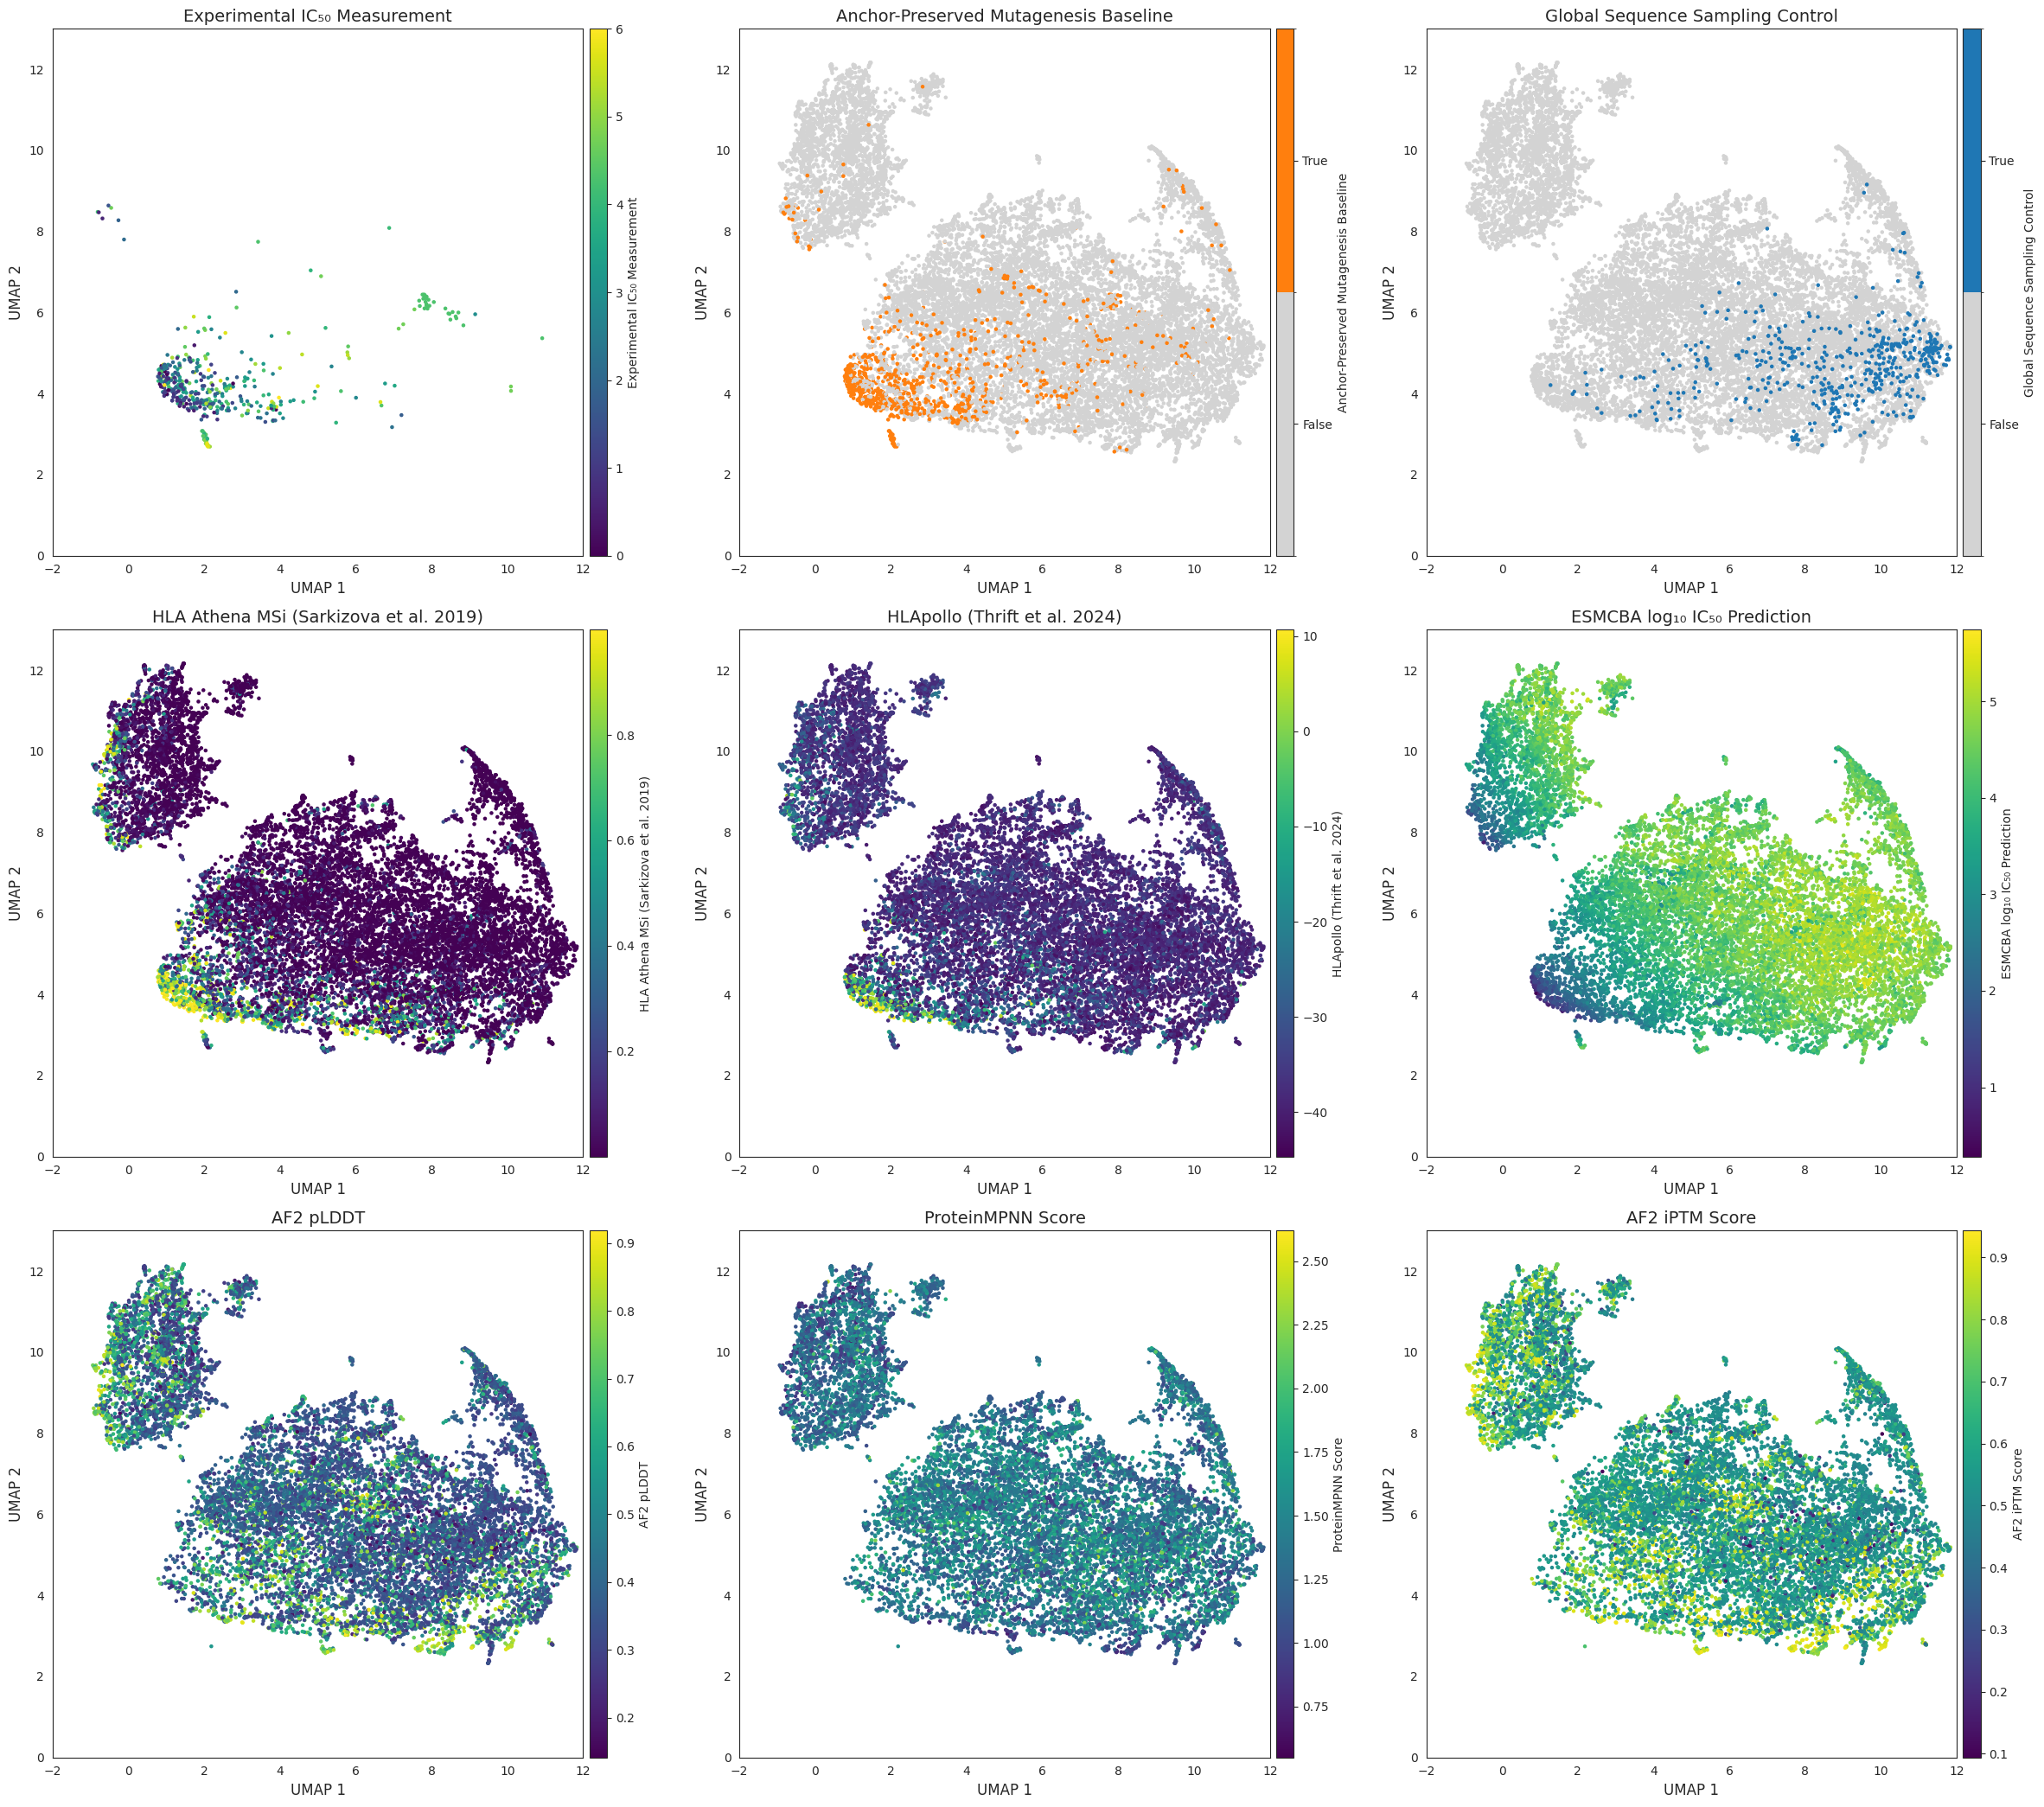

In [5]:

# Define columns for plotting
hue_columns = [
    'measured', 'PERMUTATION_TEST', 'RANDOM_SAMPLED', 'Athena_MSI',
    'mhc_pred_0', 'prediction_x', 'plddt', 'mpnn', 'i_ptm'
]

# Create subplots
n_cols = 3
n_rows = (len(hue_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 7 * n_rows))
axes = axes.flatten()

# Define discrete colormaps
perm_cmap = ListedColormap(['lightgray', 'tab:orange'])
random_cmap = ListedColormap(['lightgray', 'tab:blue'])

# Plot each hue variable
for idx, hue_var in enumerate(hue_columns):
    ax = axes[idx]
    subset = dt[dt[hue_var].notna()]
    
    # Choose colormap and normalization
    if hue_var == 'PERMUTATION_TEST':
        cmap = perm_cmap
        norm = mcolors.BoundaryNorm([0, 0.5, 1], perm_cmap.N)
    elif hue_var == 'RANDOM_SAMPLED':
        cmap = random_cmap
        norm = mcolors.BoundaryNorm([0, 0.5, 1], random_cmap.N)
    else:
        cmap = 'viridis'
        norm = None

    # Create scatter plot
    points = ax.scatter(
        subset['UMAP_1'], subset['UMAP_2'],
        c=subset[hue_var], cmap=cmap, norm=norm, s=5, edgecolor=None
    )
    
    # Set plot titles and labels
    title_str = pretty_names.get(hue_var, hue_var)
    ax.set_title(title_str, fontsize=14)
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_xlim(-2, 12)
    ax.set_ylim(0, 13)

    # Add colorbar
    cbar = fig.colorbar(points, ax=ax, orientation='vertical', pad=0.01, aspect=30)
    cbar.set_label(title_str, fontsize=10)
    
    # Set discrete ticks for baseline variables
    if hue_var in ('PERMUTATION_TEST', 'RANDOM_SAMPLED'):
        cbar.set_ticks([0.25, 0.75])
        cbar.set_ticklabels(['False', 'True'])

plt.tight_layout()
plt.show()

In [19]:
main_combined = pd.read_csv('../data/main_df_updated_with_ApolloAthenaNuggetMix.csv')[['sequence', 'MixMHCpred_%Rank',	'mhc_nuggets_ic50'	,'HLApollo_pred']]
main_combined

/tmp/ipykernel_2938861/435987155.py:1: DtypeWarning: Columns (13,14,44,45,46,47,48,49,50,52,53,54,55,57,60,62,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  main_combined = pd.read_csv('../data/main_df_updated_with_ApolloAthenaNuggetMix.csv')[['sequence', 'MixMHCpred_%Rank',	'mhc_nuggets_ic50'	,'HLApollo_pred']]


,sequence,MixMHCpred_%Rank,mhc_nuggets_ic50,HLApollo_pred
0,SDLSLGPEA,7.792164,19936.59,-38.507525
1,SSLSLGPEA,7.647168,3718.61,-37.665597
2,SSLSLGPHA,9.047483,4354.81,-39.210855
3,SSLSLGFHA,9.417264,864.03,-37.809690
4,SDLSLGFEA,8.101418,14841.26,-37.442533
...,...,...,...,...
25667,FVLASLCLYVV,0.877758,202.51,-41.735909
25668,GMLPSNYVEAI,0.808441,1501.70,-33.143410
25669,FLAFTGVAGYI,3.527624,11.98,-36.668565
25670,FLCEILRSMSI,0.932169,6.49,-36.591447


In [20]:
dt_merged = dt.merge(main_combined, left_on='sequence', right_on='sequence', how='left')

In [22]:
dt = dt_merged

In [38]:
from sklearn.metrics import roc_curve, auc

# --- Predictors (True => invert so higher = better) ---
predictor_columns = {
    "MHCflurry": ("mhc_log_y", True),
    "NetMHCpan %Rank": ("BA_Rank", True),
    "ESMCBA log IC50": ("prediction_x", True),
    "HLAthena %Rank": ("Athena_MSI", False),          
    "Apollo inverse": ("HLApollo_pred", False),
    "MHC Nugget": ("mhc_nuggets_ic50", True),
    "MixMHCPred %Rank": ("MixMHCpred_%Rank", True),
}

# --- Fixed colors per model (consistent across all panels) ---
model_colors = {
    "MHCflurry": "C0",
    "NetMHCpan %Rank": "C1",
    "ESMCBA log IC50": "C2",
    "HLAthena %Rank": "C3",
    "Apollo inverse": "C4",
    "MHC Nugget": "C5",
    "MixMHCPred %Rank": "C6",
}

# --- Panels and labels ---
def subset_and_labels(df, key):
    if key == "Validated tested\nbinders vs non-binders":
        mask = (df["measured"] < 2) | (df["measured"] > 4)
        labels = (df.loc[mask, "measured"] < 2).astype(int)

    elif key == "Validated strong\nbinders vs ESM2 random":
        mask = (df["measured"] < 2) | (df["RANDOM_SAMPLED"])
        labels = (df.loc[mask, "measured"] < 2).astype(int)

    elif key == "Anchor-preserved\nvs ESM2 random":
        mask = df["PERMUTATION_TEST"] | df["RANDOM_SAMPLED"]
        labels = df.loc[mask, "PERMUTATION_TEST"].astype(int)

    elif key == "Diffusion designs\nvs ESM2 random":
        mask = (df["plddt"] > 0.8) | (df["RANDOM_SAMPLED"])
        labels = (df.loc[mask, "plddt"] > 0.8).astype(int)

    elif key == "Diffusion designs\nvs Binders":
        mask = (df["plddt"] > 0.8) | (df["measured"] < 2)
        labels = (df.loc[mask, "plddt"] > 0.8).astype(int)

    elif key == "Diffusion designs\nvs Anchor-preserved":
        mask = (df["plddt"] > 0.8) | (df["PERMUTATION_TEST"])
        labels = (df.loc[mask, "plddt"] > 0.8).astype(int)

    else:
        raise ValueError(key)

    return mask, labels

In [42]:
eval_panels = [
    "Validated tested\nbinders vs non-binders",
    "Validated strong\nbinders vs ESM2 random",
    "Anchor-preserved\nvs ESM2 random",
    "Diffusion designs\nvs ESM2 random",
    "Diffusion designs\nvs Binders",
    "Diffusion designs\nvs Anchor-preserved",
]

def safe_scores(y):
    y = pd.to_numeric(y, errors="coerce").astype(float)
    y[~np.isfinite(y)] = np.nan
    return y.values


--- Validated tested
binders vs non-binders ---
Total samples: 293, Positives: 136, Negatives: 157

--- Validated strong
binders vs ESM2 random ---
Total samples: 638, Positives: 136, Negatives: 502

--- Anchor-preserved
vs ESM2 random ---
Total samples: 1470, Positives: 968, Negatives: 502

--- Diffusion designs
vs ESM2 random ---
Total samples: 1037, Positives: 535, Negatives: 502

--- Diffusion designs
vs Binders ---
Total samples: 671, Positives: 535, Negatives: 136

--- Diffusion designs
vs Anchor-preserved ---
Total samples: 1503, Positives: 535, Negatives: 968


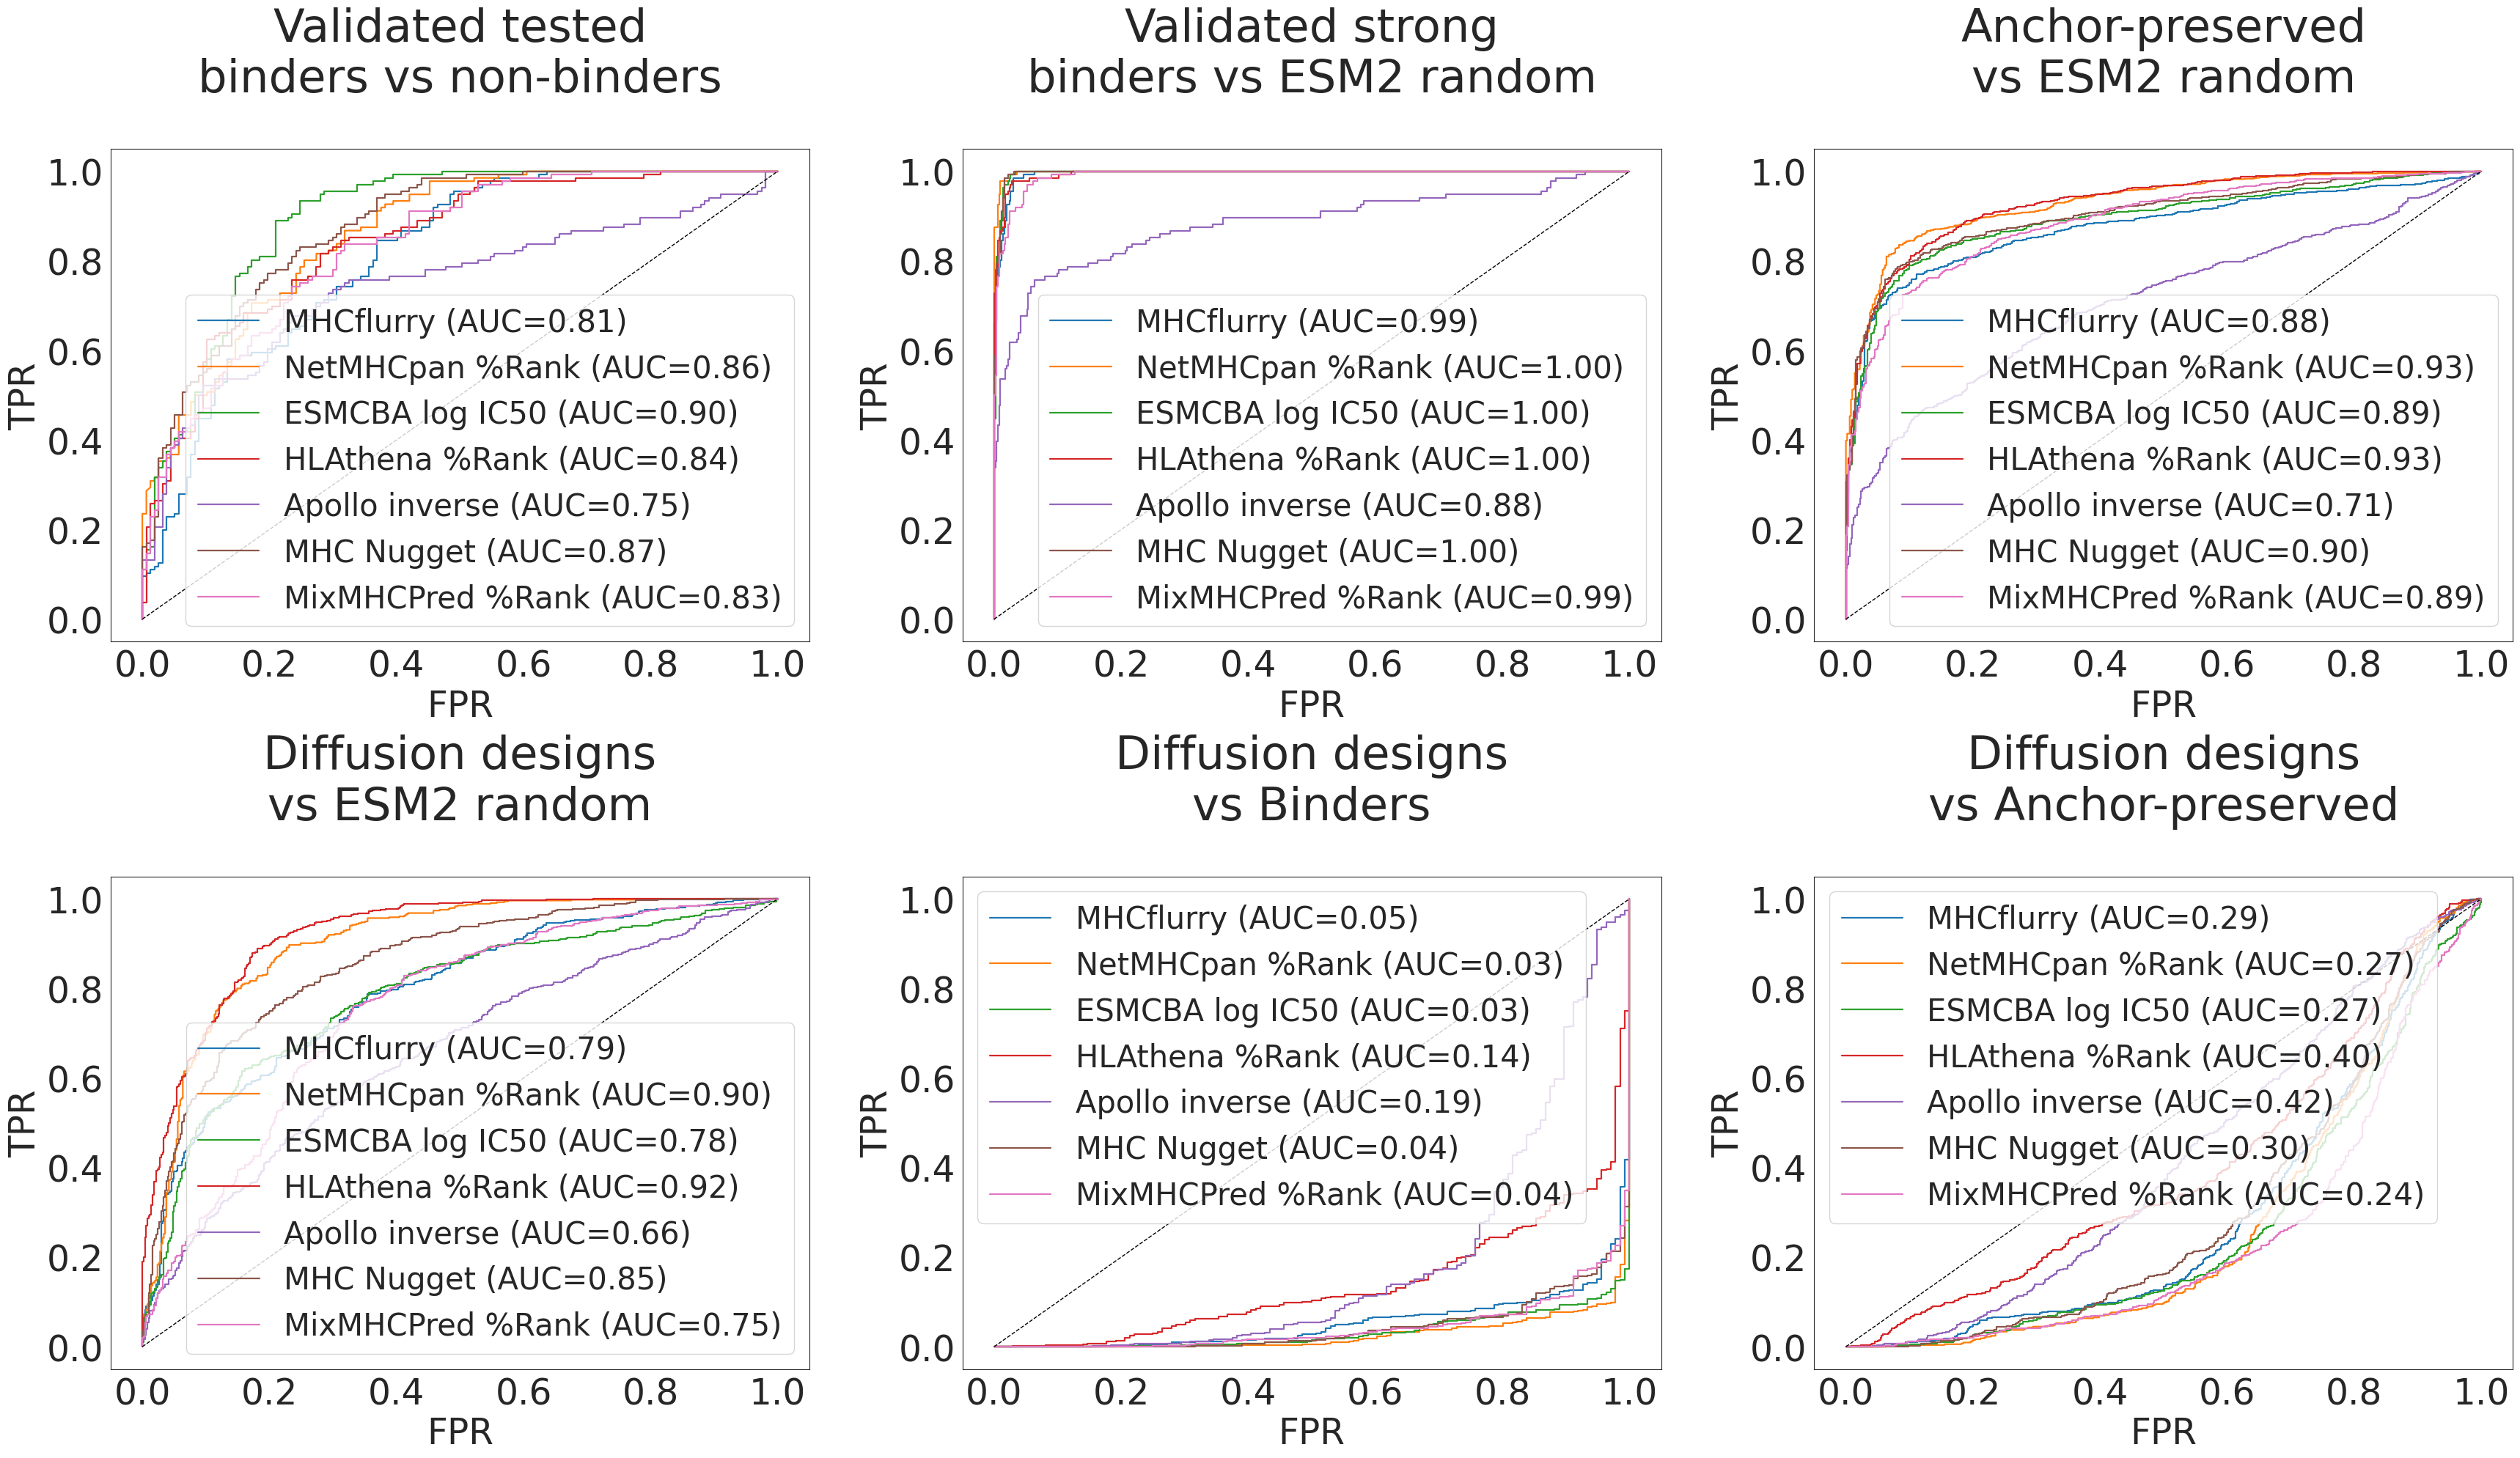

In [46]:
# --- Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(35, 20))
axes = axes.ravel()

# lock model order for legends
model_order = list(predictor_columns.keys())
for ax, key in zip(axes, eval_panels):
    print(f"\n--- {key} ---")
    mask, labels = subset_and_labels(dt, key)
    sub = dt.loc[mask].copy()
    sub["label"] = labels.values

    total = len(sub); pos = int(sub["label"].sum()); neg = total - pos
    print(f"Total samples: {total}, Positives: {pos}, Negatives: {neg}")

    plotted_any = False
    legend_handles = []

    for model_name in model_order:
        col, invert = predictor_columns[model_name]
        color = model_colors[model_name]

        can_compute = True
        if col not in sub.columns:
            print(f"⚠️  Missing column: {col} for {model_name}")
            can_compute = False
        else:
            y_true = sub["label"].values
            y_score = safe_scores(sub[col])
            valid = ~np.isnan(y_score)
            y_true = y_true[valid]
            y_score = y_score[valid]

            if y_true.size == 0 or len(np.unique(y_true)) < 2:
                print(f"⚠️  Not enough class variation for {model_name} after filtering.")
                can_compute = False

        if can_compute:
            if invert:
                y_score = -y_score
            fpr, tpr, _ = roc_curve(y_true, y_score)
            model_auc = auc(fpr, tpr)
            h, = ax.plot(fpr, tpr, lw=1.6, color=color,
                         label=f"{model_name} (AUC={model_auc:.2f})")
            legend_handles.append(h)
            plotted_any = True
        else:
            h, = ax.plot([], [], lw=1.6, color=color,
                         label=f"{model_name} (AUC=NA)")
            legend_handles.append(h)

    ax.plot([0, 1], [0, 1], "k--", lw=1)

    # Bigger titles, labels, ticks
    ax.set_title(key + '\n', fontsize=45)
    ax.set_xlabel("FPR", fontsize=35)
    ax.set_ylabel("TPR", fontsize=35)
    ax.tick_params(axis='both', which='major', labelsize=35)

    ax.grid(False)
    ax.legend(handles=legend_handles, fontsize=30, loc='best')  # best position

plt.tight_layout()
plt.savefig("../figures/benchmark_roc_curves.pdf", dpi=300)
plt.show()
